### Black–Derman–Toy Interest Rate Mdoel and Inputs

In [73]:
import numpy as np
import pandas as pd
from typing import Union, List, Tuple, Optional
from scipy.optimize import root
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [65]:
class BlackDermanToy:
    """
    Vectorized Black-Derman-Toy (BDT) short-rate model.
    Supports arbitrary uniform time steps (e.g., annual, quarterly, monthly).
    """

    def __init__(
        self,
        maturities: Union[List[float], np.ndarray],
        spot_yields: Union[List[float], np.ndarray],
        yield_vols: Union[List[float], np.ndarray],
        dt: Optional[float] = None,
    ):
        self.maturities = np.asarray(maturities, dtype=np.float64)
        self.spot_yields = np.asarray(spot_yields, dtype=np.float64)
        self.yield_vols = np.asarray(yield_vols, dtype=np.float64)
        self.n_steps = len(self.maturities)

        self.dt = float(dt) if dt is not None else float(self.maturities[0])
        
        expected_grid = self.dt * (np.arange(self.n_steps) + 1)
        if not np.allclose(self.maturities, expected_grid, rtol=0, atol=1e-8):
            raise ValueError(f"Maturities must form a uniform grid with step {self.dt}.")

        self.sqrt_dt = np.sqrt(self.dt)
        self.market_zero_prices = (1.0 + self.spot_yields) ** (-self.maturities)

        self.short_rate_tree: List[np.ndarray] = []
        self.state_prices: List[np.ndarray] = []
        self.rate_vol_multipliers: List[float] = []

    @classmethod
    def monthly(cls, n_months: int, spot_yields, yield_vols) -> "BlackDermanToy":
        maturities = (np.arange(n_months) + 1) / 12.0
        return cls(maturities, spot_yields, yield_vols, dt=1.0 / 12.0)

    def _discount(self, rates: np.ndarray) -> np.ndarray:
        return (1.0 + rates) ** (-self.dt)

    def _forward_step(self, state_prices: np.ndarray, short_rates: np.ndarray) -> np.ndarray:
        v = state_prices * self._discount(short_rates)
        return 0.5 * (np.pad(v, (0, 1)) + np.pad(v, (1, 0)))

    def calibrate(self) -> "BlackDermanToy":
        self.short_rate_tree.append(np.array([self.spot_yields[0]]))
        self.state_prices.append(np.array([1.0]))
        self.rate_vol_multipliers.append(1.0)

        ad_down, ad_up = np.array([]), np.array([])

        for t in range(1, self.n_steps):
            ad_t = self._forward_step(self.state_prices[-1], self.short_rate_tree[-1])
            self.state_prices.append(ad_t)

            target_price = self.market_zero_prices[t]
            states = np.arange(t + 1)
            tau = t * self.dt

            if t == 1:
                multiplier = float(np.exp(2.0 * self.yield_vols[1] * self.sqrt_dt))
                growth = multiplier ** states

                def objective_t1(r_base: np.ndarray) -> float:
                    return float(np.dot(ad_t, self._discount(r_base[0] * growth)) - target_price)

                sol = root(objective_t1, [self.spot_yields[t]], method="hybr")
                if not sol.success:
                    raise RuntimeError(f"Calibration failed at step {t}: {sol.message}")
                
                self.short_rate_tree.append(sol.x[0] * growth)
                self.rate_vol_multipliers.append(multiplier)
                
                ad_down, ad_up = np.array([1.0, 0.0]), np.array([0.0, 1.0])
            else:
                ad_down = self._forward_step(ad_down, self.short_rate_tree[-1])
                ad_up = self._forward_step(ad_up, self.short_rate_tree[-1])

                vol_target = self.yield_vols[t]

                def calibration_system(params: Tuple[float, float]) -> List[float]:
                    r_base, mult = params
                    rates = r_base * (mult ** states)
                    df = self._discount(rates)

                    price_model = np.dot(ad_t, df)
                    y_down = pow(np.dot(ad_down, df), -1.0 / tau) - 1.0
                    y_up = pow(np.dot(ad_up, df), -1.0 / tau) - 1.0

                    eq_price = price_model - target_price
                    eq_vol = y_down * np.exp(2.0 * vol_target * self.sqrt_dt) - y_up
                    return [eq_vol, eq_price]

                init_guess = [self.spot_yields[t] * 0.8, np.exp(2.0 * vol_target * self.sqrt_dt)]
                sol = root(calibration_system, init_guess, method="hybr")
                if not sol.success:
                    raise RuntimeError(f"Calibration failed at step {t}: {sol.message}")

                r_base, multiplier = float(sol.x[0]), float(sol.x[1])
                self.short_rate_tree.append(r_base * (multiplier ** states))
                self.rate_vol_multipliers.append(multiplier)

        return self

    def price_caplet(self, reset_time: int, strike: float, notional: float = 1.0) -> float:
        if reset_time >= self.n_steps:
            raise ValueError(f"Reset time {reset_time} exceeds tree horizon.")
        
        rates = self.short_rate_tree[reset_time]
        discounted_payoff = self.dt * notional * np.maximum(rates - strike, 0.0) * self._discount(rates)
        return float(np.dot(self.state_prices[reset_time], discounted_payoff))

    def price_cap(self, strike: float, notional: float = 1.0) -> float:
        return sum(self.price_caplet(t, strike, notional) for t in range(1, self.n_steps))

    def rollback(self, terminal_payoff: np.ndarray, maturity_step: int) -> float:
        values = np.asarray(terminal_payoff, dtype=np.float64)
        for t in range(maturity_step - 1, -1, -1):
            values = 0.5 * (values[1:] + values[:-1]) * self._discount(self.short_rate_tree[t])
        return float(values[0])

    def to_dataframe(self) -> pd.DataFrame:
        df = pd.DataFrame(index=range(self.n_steps), columns=[f"t={t}" for t in range(self.n_steps)], dtype=float)
        for t, rates in enumerate(self.short_rate_tree):
            df.iloc[:len(rates), t] = rates
        return df

    def price_callable_floater(
        self,
        face_value: float = 100.0,
        spread: float = 0.0,
        cap_rate: Optional[float] = None,
        floor_rate: Optional[float] = None,
        call_schedule: Optional[dict] = None,
    ) -> float:
        T = self.n_steps - 1
        call_schedule = call_schedule or {}
        v_ex = np.full(T + 1, face_value, dtype=np.float64)

        for t in range(T - 1, -1, -1):
            rates = self.short_rate_tree[t]
            exp_v_next = 0.5 * (v_ex[1:] + v_ex[:-1])
            
            c = rates + spread
            if cap_rate is not None:
                c = np.minimum(c, cap_rate)
            if floor_rate is not None:
                c = np.maximum(c, floor_rate)
                
            coupon_next = face_value * c * self.dt
            continuation = (exp_v_next + coupon_next) * self._discount(rates)

            if t > 0 and t in call_schedule:
                v_ex = np.minimum(continuation, call_schedule[t])
            else:
                v_ex = continuation

        return float(v_ex[0])
    
    def price_european_swaption(
        self, 
        t_ex: int, 
        t_end: int, 
        strike: float, 
        is_payer: bool = True, 
        notional: float = 100.0
    ) -> float:
        """
        Prices a European Swaption.
        t_ex:  Time step when the option expires (swaption maturity).
        t_end: Time step when the underlying swap terminates.
        """
        if t_end > self.n_steps:
            raise ValueError(f"Swap end time {t_end} exceeds tree horizon.")
        if t_ex >= t_end:
            raise ValueError("Exercise time must be strictly before swap end time.")
            
        # 1. At the very end of the swap, its remaining value is zero.
        v_swap = np.zeros(t_end + 1, dtype=np.float64)
        
        # 2. Roll backward from t_end down to the exercise date t_ex
        for t in range(t_end - 1, t_ex - 1, -1):
            rates = self.short_rate_tree[t]
            exp_v_next = 0.5 * (v_swap[1:] + v_swap[:-1])
            
            # The swap pays out (Rate - Strike) * dt at the next period, discounted back
            if is_payer:
                cf_next = (rates - strike) * self.dt
            else:
                cf_next = (strike - rates) * self.dt
                
            v_swap = (exp_v_next + cf_next) * self._discount(rates)
            
        # 3. Swaption Payoff at t_ex: max(V_swap, 0)
        payoff = np.maximum(v_swap, 0.0) * notional
        
        # 4. Discount payoff to today using Arrow-Debreu state prices
        return float(np.dot(self.state_prices[t_ex], payoff))


class BDTVisualizer:
    """
    Visualization utilities for the Black-Derman-Toy model.
    """

    COLOR_YIELD = "#0284c7"  
    COLOR_VOL = "#dc2626"    
    NODE_COLOR = "#e0f2fe"   
    EDGE_COLOR = "#0284c7"   
    LINE_COLOR = "gray"

    @staticmethod
    def _percentage_formatter(x: float, pos: int) -> str:
        return f"{x:.1%}"

    @classmethod
    def plot_dashboard(cls, model: "BlackDermanToy", figsize: Tuple[int, int] = (16, 7)) -> None:
        if not model.short_rate_tree:
            raise ValueError("The model must be calibrated before plotting.")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        cls._plot_market_inputs(model, ax1)
        cls._plot_lattice(model, ax2)
        
        plt.tight_layout()
        plt.show()

    @classmethod
    def _plot_market_inputs(cls, model: "BlackDermanToy", ax: plt.Axes) -> None:
        ax.plot(model.maturities, model.spot_yields, marker="o", color=cls.COLOR_YIELD, linewidth=2, label="Spot Yield")
        ax.set_xlabel("Maturity (Years)", fontweight="bold")
        ax.set_ylabel("Spot Yield", color=cls.COLOR_YIELD, fontweight="bold")
        ax.tick_params(axis="y", labelcolor=cls.COLOR_YIELD)
        ax.yaxis.set_major_formatter(FuncFormatter(cls._percentage_formatter))
        
        ax_vol = ax.twinx()
        vols_clean = np.where(np.isnan(model.yield_vols), np.nan, model.yield_vols)
        
        ax_vol.plot(model.maturities, vols_clean, marker="s", color=cls.COLOR_VOL, linewidth=2, linestyle="--", label="Yield Volatility")
        ax_vol.set_ylabel("Yield Volatility", color=cls.COLOR_VOL, fontweight="bold")
        ax_vol.tick_params(axis="y", labelcolor=cls.COLOR_VOL)
        ax_vol.yaxis.set_major_formatter(FuncFormatter(cls._percentage_formatter))
        
        ax.set_title("Market Inputs: Yield & Volatility Term Structure", fontsize=14, pad=15)
        ax.grid(True, linestyle=":", alpha=0.6)

    @classmethod
    def _plot_lattice(cls, model: "BlackDermanToy", ax: plt.Axes) -> None:
        n_steps = model.n_steps
        
        # Dynamically scale node and font sizes based on tree depth
        node_size = max(300, 2500 - (n_steps * 120))
        font_size = max(5, 10 - (n_steps * 0.3))
        
        for t in range(n_steps):
            rates = model.short_rate_tree[t]
            for i, rate in enumerate(rates):
                # x is time (columns), y is state (rows)
                x = t
                y = i
                
                # Render Node
                ax.scatter(x, y, s=node_size, c=cls.NODE_COLOR, edgecolors=cls.EDGE_COLOR, zorder=2)
                
                # Render Rate Text
                ax.text(x, y, f"{rate:.1%}", ha="center", va="center", fontsize=font_size, fontweight="bold", zorder=3)
                
                # Render Forward Branches
                if t < n_steps - 1:
                    # Horizontal move to the right maps to the same row index (Down move)
                    ax.plot([x, t + 1], [y, y], color=cls.LINE_COLOR, zorder=1, alpha=0.6)
                    # Diagonal move to the next row index (Up move)
                    ax.plot([x, t + 1], [y, y + 1], color=cls.LINE_COLOR, zorder=1, alpha=0.6)
                    
        ax.set_title(f"Calibrated BDT Short-Rate Lattice ({n_steps}-Steps)", fontsize=14, pad=15)
        
        # INVERT Y-AXIS to perfectly match Pandas DataFrame row ordering (Row 0 at top)
        ax.invert_yaxis()
        
        ax.axis("off")


In [66]:
# create product types
def product_list(bdt):
    strike = 0.12
    print(f"Total {strike*100}% Cap Value: {bdt.price_cap(strike):.4f}")

    print("\n--- Callable Variable-Rate Bond Pricing ---")
    # a) Plain Floater (Fundamental Theorem: Must price exactly at Par)
    px_plain = bdt.price_callable_floater()
    print(f"Plain Floater (Par Check): {px_plain:.4f}")

    # b) Floater with +200 bps spread
    px_uncallable = bdt.price_callable_floater(spread=0.02)
    print(f"Floater +2% Spread (Uncallable): {px_uncallable:.4f}")

    # c) Callable Floater (+200 bps spread, callable at Par at t=1 and t=2)
    px_callable = bdt.price_callable_floater(spread=0.02, call_schedule={1: 100.0, 2: 100.0})
    print(f"Floater +2% Spread (Callable): {px_callable:.4f}")

    # d) Implied Issuer Call Option Value
    print(f"Embedded Call Option Value: {px_uncallable - px_callable:.4f}")

    # e) Floater with +200 bps spread and a 15% Cap on coupons
    px_capped = bdt.price_callable_floater(spread=0.02, cap_rate=0.15)
    print(f"Floater +2% Spread (15% Cap): {px_capped:.4f}")

    # f) Swaption
    print("\n--- European Swaption Pricing ---")
    # Option expires at t=5. The underlying swap runs from t=5 to t=15.
    # Strike is 5.0%
    px_swaption = bdt.price_european_swaption(t_ex=5, t_end=15, strike=0.05, is_payer=True)
    print(f"5y10y Payer Swaption (Strike 5.0%): {px_swaption:.4f}")

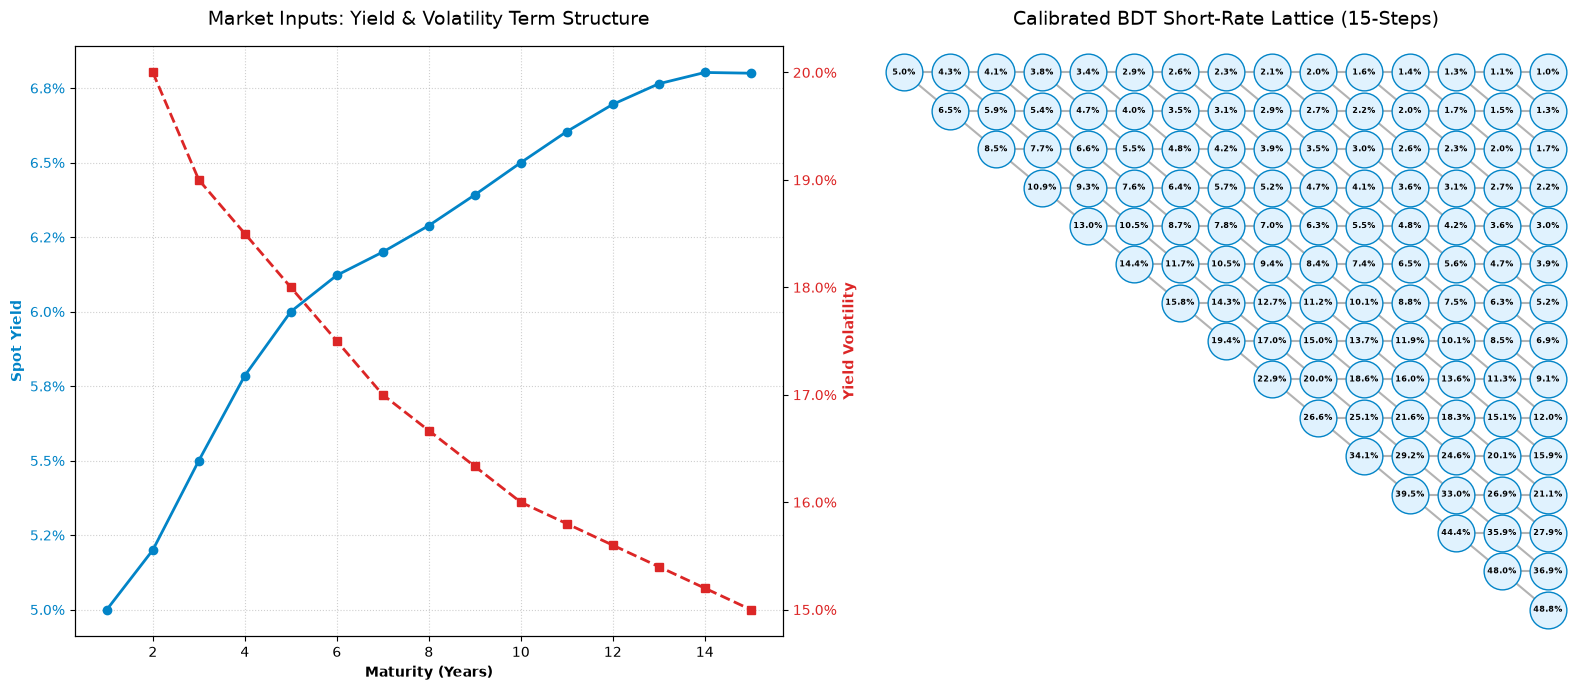

In [67]:
# 1. Market Inputs - Current
raw_tenors = np.array([1, 2, 3, 5, 7, 10, 15])
raw_yields = np.array([0.050, 0.052, 0.055, 0.060, 0.062, 0.065, 0.068])
raw_vols = np.array([np.nan, 0.20, 0.19, 0.18, 0.17, 0.16, 0.15]) 

# --- Interpolation Step to create a Uniform Grid for BDT ---
dt = 1.0

# Creates a uniform grid: [1.0, 2.0, 3.0, ..., 15.0]
maturities = np.arange(dt, 15 + dt, dt) 

# Interpolate yields using a smooth Cubic Spline
spot_yields = CubicSpline(raw_tenors, raw_yields)(maturities)

# Interpolate vols using linear interpolation
valid_vol_idx = ~np.isnan(raw_vols)
yield_vols = np.interp(maturities, raw_tenors[valid_vol_idx], raw_vols[valid_vol_idx])
yield_vols[0] = np.nan # t=1 vol is not used by the model

# 2. Initialize and Calibrate
bdt = BlackDermanToy(maturities, spot_yields, yield_vols).calibrate()
# print(bdt.to_dataframe().to_string())

# 3. Call the visualizer! (This generates the dual-panel chart)
BDTVisualizer.plot_dashboard(bdt)

In [68]:
product_list(bdt)

Total 12.0% Cap Value: 0.0128

--- Callable Variable-Rate Bond Pricing ---
Plain Floater (Par Check): 100.0000
Floater +2% Spread (Uncallable): 118.2167
Floater +2% Spread (Callable): 101.9048
Embedded Call Option Value: 16.3119
Floater +2% Spread (15% Cap): 117.3890

--- European Swaption Pricing ---
5y10y Payer Swaption (Strike 5.0%): 12.0089


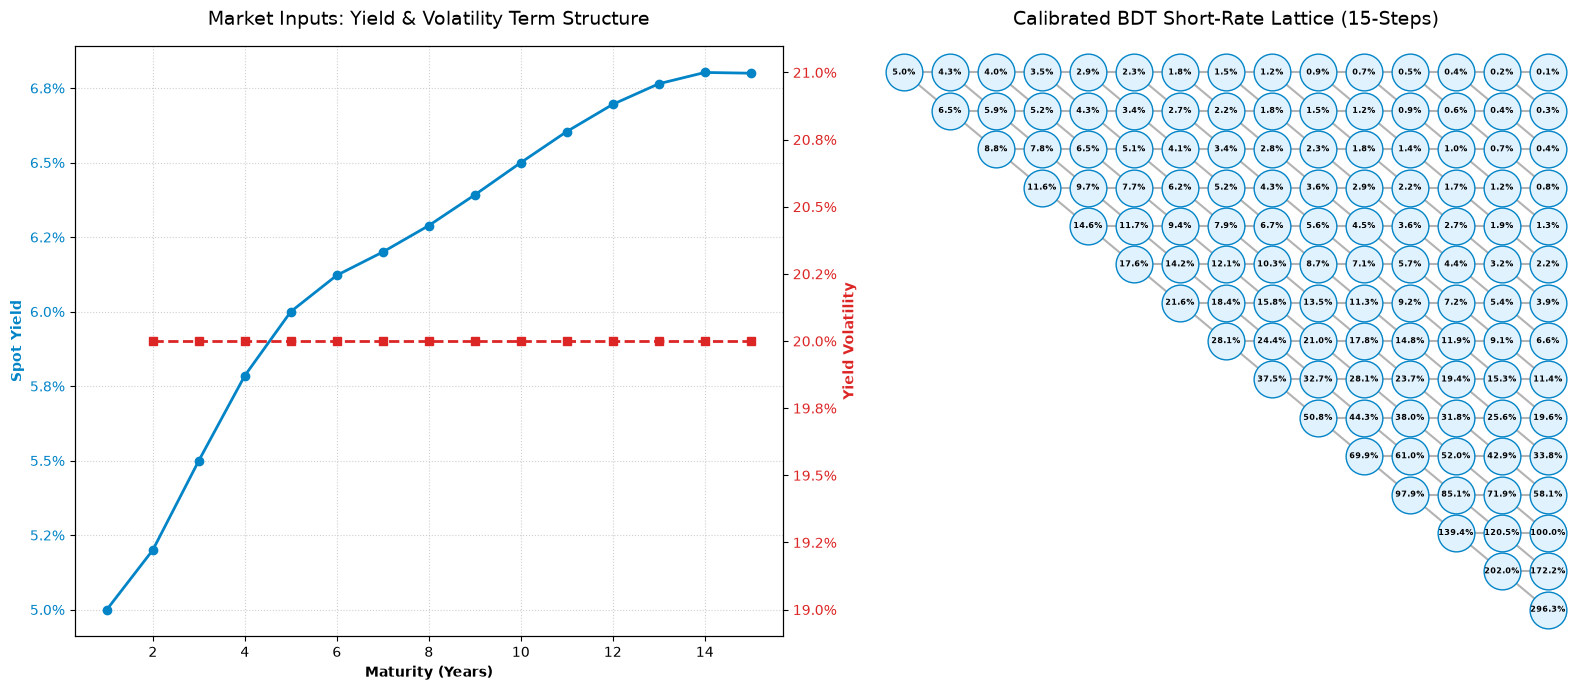

In [69]:
# 1. Market Inputs - Fix Vol
raw_tenors = np.array([1, 2, 3, 5, 7, 10, 15])
raw_yields = np.array([0.050, 0.052, 0.055, 0.060, 0.062, 0.065, 0.068])
raw_vols = np.array([np.nan, 0.20, 0.20, 0.20, 0.20, 0.20, 0.20]) 

# --- Interpolation Step to create a Uniform Grid for BDT ---
dt = 1.0

# Creates a uniform grid: [1.0, 2.0, 3.0, ..., 15.0]
maturities = np.arange(dt, 15 + dt, dt) 

# Interpolate yields using a smooth Cubic Spline
spot_yields = CubicSpline(raw_tenors, raw_yields)(maturities)

# Interpolate vols using linear interpolation
valid_vol_idx = ~np.isnan(raw_vols)
yield_vols = np.interp(maturities, raw_tenors[valid_vol_idx], raw_vols[valid_vol_idx])
yield_vols[0] = np.nan # t=1 vol is not used by the model

# 2. Initialize and Calibrate
bdt = BlackDermanToy(maturities, spot_yields, yield_vols).calibrate()
# print(bdt.to_dataframe().to_string())

# 3. Call the visualizer! (This generates the dual-panel chart)
BDTVisualizer.plot_dashboard(bdt)

In [70]:
product_list(bdt)

Total 12.0% Cap Value: 0.0382

--- Callable Variable-Rate Bond Pricing ---
Plain Floater (Par Check): 100.0000
Floater +2% Spread (Uncallable): 118.2167
Floater +2% Spread (Callable): 101.9048
Embedded Call Option Value: 16.3119
Floater +2% Spread (15% Cap): 115.3779

--- European Swaption Pricing ---
5y10y Payer Swaption (Strike 5.0%): 13.2138


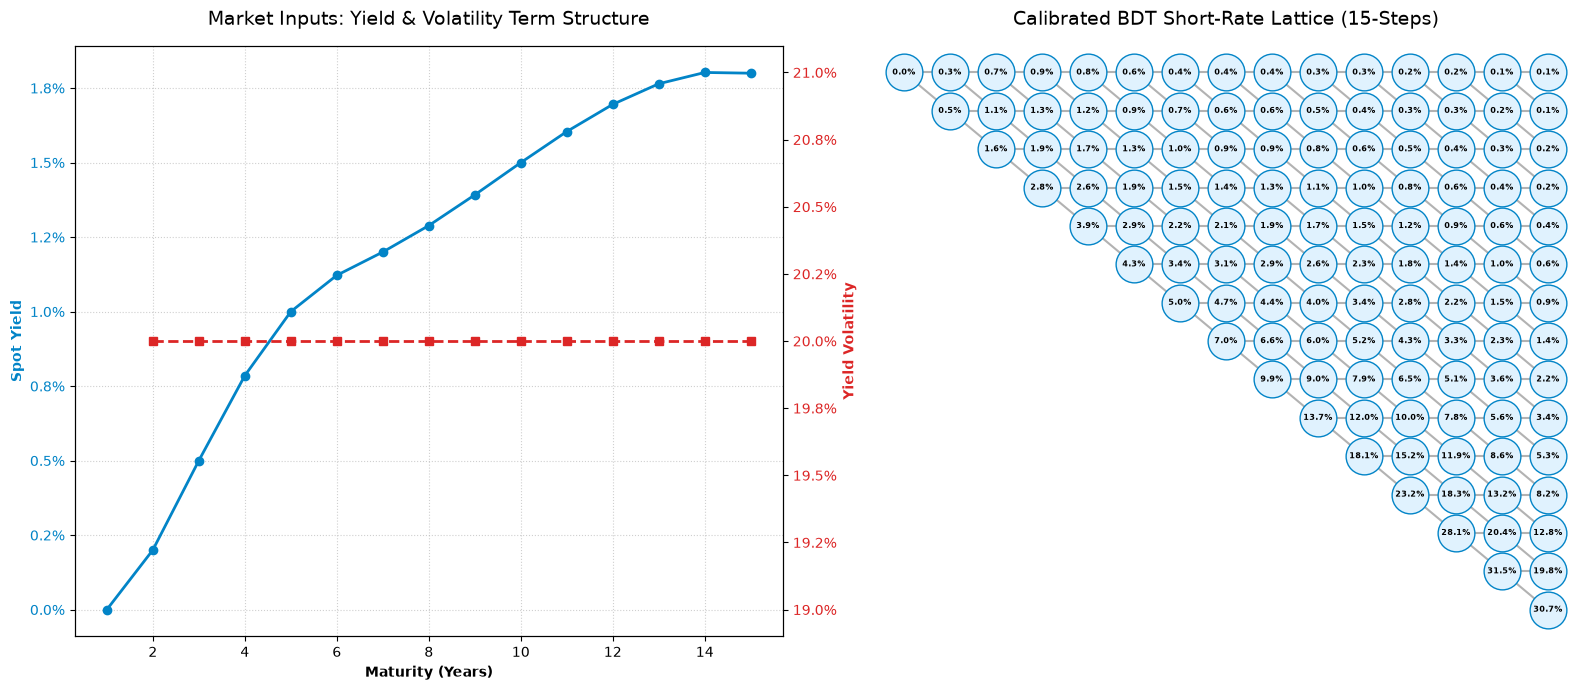

In [71]:
# 1. Market Inputs - Low Rate enviroments
raw_tenors = np.array([1, 2, 3, 5, 7, 10, 15])
raw_yields = np.array([0.050, 0.052, 0.055, 0.060, 0.062, 0.065, 0.068]) - 0.05
raw_vols = np.array([np.nan, 0.20, 0.20, 0.20, 0.20, 0.20, 0.20]) 

# --- Interpolation Step to create a Uniform Grid for BDT ---
dt = 1.0

# Creates a uniform grid: [1.0, 2.0, 3.0, ..., 15.0]
maturities = np.arange(dt, 15 + dt, dt) 

# Interpolate yields using a smooth Cubic Spline
spot_yields = CubicSpline(raw_tenors, raw_yields)(maturities)

# Interpolate vols using linear interpolation
valid_vol_idx = ~np.isnan(raw_vols)
yield_vols = np.interp(maturities, raw_tenors[valid_vol_idx], raw_vols[valid_vol_idx])
yield_vols[0] = np.nan # t=1 vol is not used by the model

# 2. Initialize and Calibrate
bdt = BlackDermanToy(maturities, spot_yields, yield_vols).calibrate()
# print(bdt.to_dataframe().to_string())

# 3. Call the visualizer! (This generates the dual-panel chart)
BDTVisualizer.plot_dashboard(bdt)

In [72]:
product_list(bdt)

Total 12.0% Cap Value: 0.0004

--- Callable Variable-Rate Bond Pricing ---
Plain Floater (Par Check): 100.0000
Floater +2% Spread (Uncallable): 125.2726
Floater +2% Spread (Callable): 102.0000
Embedded Call Option Value: 23.2726
Floater +2% Spread (15% Cap): 125.2469

--- European Swaption Pricing ---
5y10y Payer Swaption (Strike 5.0%): 0.1263
